# Prédiction des charges d’assurance – Analyse exploratoire (EDA)

## Contexte
Un assureur souhaite anticiper les charges médicales à partir de variables
démographiques et de santé afin d’améliorer la tarification et la gestion du risque.

## Objectifs de ce notebook
- Comprendre la structure et la qualité des données
- Identifier les variables influençant les charges
- Mettre en évidence des insights métier
- Préparer les choix de modélisation pour la semaine 2


### Dictionnaire des Variables

| Variable | Type | Rôle | Description |
| :--- | :--- | :--- | :--- |
| **age** | Numérique | Feature | Âge de l'assuré (18-64 ans) |
| **sex** | Catégorielle | Feature | Sexe (male/female) |
| **bmi** | Numérique | Feature | Indice de Masse Corporelle (IMC) |
| **children** | Numérique | Feature | Nombre d'enfants à charge |
| **smoker** | Catégorielle | Feature | Fumeur (yes/no) |
| **region** | Catégorielle | Feature | Région aux USA (4 zones) |
| **charges** | Numérique | **Cible** | Frais médicaux annuels |

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px


# 1. Chargement des données (Chemin pour dossier /notebooks)
path = '../data/insurance.csv'

if os.path.exists(path):
    # Création d'un dictionnaire pour forcer le typage (Par défaut Pandas attribue toujours le type de données à la mémoire la plus élevée)
    df_without_optimized = pd.read_csv(path, low_memory=True)
    dtype_dict = {'age': 'int8', 'sex': 'category', 'bmi': 'float64', 'children': 'int8', 'smoker': 'category', 'region': 'category', 'charges': 'float32'}

    df = pd.read_csv(path, low_memory=True, dtype=dtype_dict)
    df["smoker_encoded"] = df["smoker"].map({"yes": 1, "no": 0}).astype("bool")
    print(df.sex.shape)
    print("Avant optimisation :")
    print("Utilisation mémoire par colonne :")
    print(f"  Niveau : {df_without_optimized.memory_usage(deep=True)} bytes")

    print(f"\nTotal : {df_without_optimized.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print("\nAprès optimisation :")
    print("Utilisation mémoire par colonne :")
    print(f"  Niveau : {df.memory_usage(deep=True)} bytes")

    print("Utilisation mémoire par colonne :")
    
    print(f"\nTotal : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print(" Les données sont prêtes pour l'analyse de la Semaine 1.")
    lines, cols = df.shape
    print(f"Dataset : {lines} lignes et {cols} colonnes.")
    df["smoker_label"] = df["smoker_encoded"].map({True: "Smoker", False: "No-smoker"})
else:
    print(f" Erreur : Je ne trouve pas le fichier au chemin : {path}")
    print("Vérifie bien que ton notebook est dans  le dossier 'notebooks'.")


df.isna().sum()

(1338,)
Avant optimisation :
Utilisation mémoire par colonne :
  Niveau : Index         132
age         10704
sex         72238
bmi         10704
children    10704
smoker      68512
region      77604
charges     10704
dtype: int64 bytes

Total : 255.18 KB

Après optimisation :
Utilisation mémoire par colonne :
  Niveau : Index               132
age                1338
sex                1446
bmi               10704
children           1338
smoker             1549
region             1742
charges            5352
smoker_encoded     1338
dtype: int64 bytes
Utilisation mémoire par colonne :

Total : 24.35 KB
 Les données sont prêtes pour l'analyse de la Semaine 1.
Dataset : 1338 lignes et 8 colonnes.


age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
smoker_encoded    0
smoker_label      0
dtype: int64

In [14]:
# Fixation de la graine aléatoire pour la reproductibilité
import numpy as np
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Graine aléatoire fixée à : {RANDOM_SEED}")

Graine aléatoire fixée à : 42


In [15]:
# 3 Informations sur le DataFrame
# contrôle des doublons
number_duplicated = df.duplicated().sum()
print(f"Il y a {number_duplicated} doublon")
# Visualiser le doublon
print(df[df.duplicated()])

# Voir toutes les lignes concernées
print(df[df.duplicated(keep=False)])
# Vérifier doublons sur les colonnes clés
df.duplicated(subset=["age","sex","bmi","children","smoker_encoded","region"]).sum()

df[df.duplicated(keep=False)]

# les lignes concerné sont strictement identique, nous avons donc choisi de le supprimer
# Suppression des doublons
df = df.drop_duplicates()

# Vérification après suppression
print(df.duplicated().sum())


# Vérification de valeur null
print(df.isnull().sum())

print("Aucune valeur null")



Il y a 1 doublon
     age   sex    bmi  children smoker     region     charges  smoker_encoded  \
581   19  male  30.59         0     no  northwest  1639.56311           False   

    smoker_label  
581    No-smoker  
     age   sex    bmi  children smoker     region     charges  smoker_encoded  \
195   19  male  30.59         0     no  northwest  1639.56311           False   
581   19  male  30.59         0     no  northwest  1639.56311           False   

    smoker_label  
195    No-smoker  
581    No-smoker  
0
age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
smoker_encoded    0
smoker_label      0
dtype: int64
Aucune valeur null


In [16]:
# Statistiques de base : mean, median, std, min, max, quartiles
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.122070
std,14.044333,6.100468,1.205571,12110.359375
min,18.000000,15.960000,0.000000,1121.873901
25%,27.000000,26.290000,0.000000,4746.344238
50%,39.000000,30.400000,1.000000,9386.161133
75%,51.000000,34.700000,2.000000,16657.716797
max,64.000000,53.130000,5.000000,63770.429688


In [17]:
# Nombre de valeurs uniques par colonne
df.nunique()



age                 47
sex                  2
bmi                548
children             6
smoker               2
region               4
charges           1337
smoker_encoded       2
smoker_label         2
dtype: int64

# 2. Analyse Univariée (Distributions)

Analyse de chaque variable indépendamment pour comprendre leur répartition et détecter d'éventuels problèmes (skewness, outliers).

## 2.1 Variables numériques

### Les charges

In [18]:
print(df["charges"].describe())

count     1337.000000
mean     13279.122070
std      12110.359375
min       1121.873901
25%       4746.344238
50%       9386.161133
75%      16657.716797
max      63770.429688
Name: charges, dtype: float64


In [19]:
f"{df.charges.sum():,.0f}"


'17,754,186'

In [20]:
df["charges"].skew()

np.float32(1.5153909)

In [21]:

fig = px.histogram(
    df,
    x="charges",
    nbins=50,
    opacity=0.75,
    title="Distribution des charges d'assurance"
)

fig.update_layout(
    xaxis_title="Charges",
    yaxis_title="Assurés",
    bargap=0.1
)

fig.show()

In [22]:
fig = px.box(
    df,
    x=df["charges"],
   
    title="Distribution des charges d'assurance",
    labels={
        "charges": "Charges d’assurance"
    }
)

fig.show()


La distribution des charges est fortement asymétrique à droite.
La majorité des observations se concentre sur des montants relativement faibles,
tandis qu’un nombre limité d’assurés présente des charges très élevées.

La moyenne est nettement supérieure à la médiane, ce qui confirme
l’influence importante des valeurs extrêmes sur la distribution.

Le boxplot met en évidence de nombreux outliers supérieurs,
et l’écart interquartile élevé traduit une forte dispersion des coûts.

D’un point de vue métier, cette distribution reflète un phénomène classique
en assurance santé : une minorité d’assurés concentre une part significative
des dépenses médicales.

Ces profils à coûts élevés représentent un risque financier majeur
pour l’assureur et justifient une attention particulière dans
les modèles de tarification et de gestion du risque.

Le coefficient d’asymétrie est élevé, confirmant une distribution
fortement déséquilibrée vers les charges élevées.




In [23]:
q1 = df["charges"].quantile(0.25)
q3 = df["charges"].quantile(0.75)
iqr = q3 - q1

q1, q3, iqr

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

q1, q3, iqr, lower_bound, upper_bound


(np.float64(4746.34423828125),
 np.float64(16657.716796875),
 np.float64(11911.37255859375),
 np.float64(-13120.714599609375),
 np.float64(34524.775634765625))

In [24]:
outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print(outliers)

      age     sex     bmi  children smoker     region       charges  \
14     27    male  42.130         0    yes  southeast  39611.757812   
19     30    male  35.300         0    yes  southwest  36837.468750   
23     34  female  31.920         1    yes  northeast  37701.875000   
29     31    male  36.300         2    yes  southwest  38711.000000   
30     22    male  35.600         0    yes  southwest  35585.574219   
...   ...     ...     ...       ...    ...        ...           ...   
1300   45    male  30.360         0    yes  southeast  62592.875000   
1301   62    male  30.875         3    yes  northwest  46718.164062   
1303   43    male  27.800         0    yes  southwest  37829.722656   
1313   19  female  34.700         2    yes  southwest  36397.574219   
1323   42  female  40.370         2    yes  southeast  43896.375000   

      smoker_encoded smoker_label  
14              True       Smoker  
19              True       Smoker  
23              True       Smoker  
29 

### Les Ages

In [25]:
df["age"].describe()

count    1337.000000
mean       39.222139
std        14.044333
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [26]:
df["age"].skew()

np.float64(0.054780773126998195)

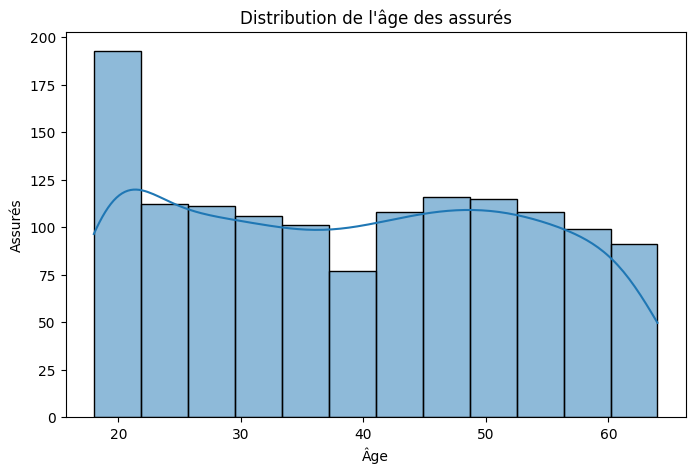

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True)
plt.title("Distribution de l'âge des assurés")
plt.xlabel("Âge")
plt.ylabel("Assurés")
plt.show()


In [28]:
bins_age = [18, 30, 40, 50, 60, 100]
labels_age = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins_age,
    labels=labels_age,
    right=False
)

fig = px.box(
    df,
    x="age_group",
   
    title="Distribution des charges par classe d’âge",
    labels={
        "age_group": "Classe d’âge",
        "charges": "Charges d’assurance"
    }
)

fig.show()

fig2 = px.histogram(
    df,
    x="age_group",
    y="charges",
    nbins=50,
    opacity=0.75,
    title="Distribution des charges d'assurance",
    category_orders={
        "age_group": ["18-29", "30-39", "40-49", "50-59", "60+"]
    }
)

fig2.show()





In [29]:
fig = px.box(
    df,
    x=df["age"],
   
    title="Distribution des âges",
    labels={
        "age": "Âges"
    }
)

fig.show()


La distribution de l’âge est relativement uniforme sur l’intervalle observé,
avec une légère concentration autour des âges moyens.
La moyenne et la médiane sont proches, indiquant une distribution
globalement symétrique, sans asymétrie marquée.

Le boxplot ne met pas en évidence de valeurs extrêmes significatives.


D’un point de vue métier, la population assurée couvre un large éventail d’âges,
ce qui permet au modèle d’apprendre des profils de risque variés.
L’âge est un facteur naturellement lié à la consommation de soins
et constitue une variable explicative pertinente pour la prédiction des charges.


La variable `age` ne nécessite pas de traitement particulier concernant
les valeurs extrêmes. Une standardisation pourra néanmoins être appliquée
afin d’assurer une mise à l’échelle cohérente avec les autres variables numériques.


### Le BMI

In [30]:
df["bmi"].describe()

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

In [31]:
df["bmi"].skew()

np.float64(0.28391419385321137)

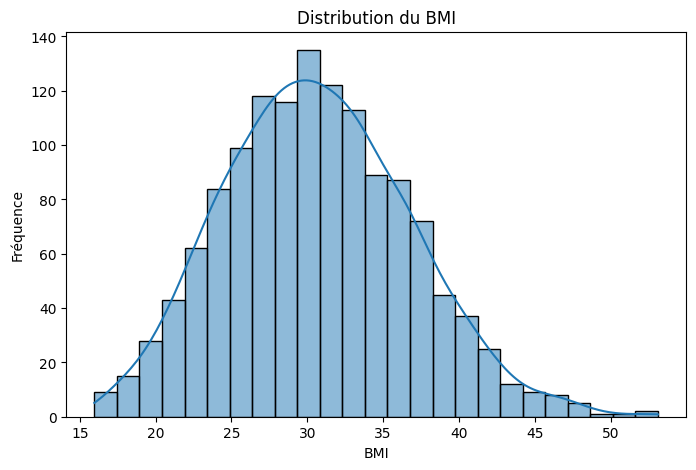

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Fréquence")
plt.show()

In [33]:
bins_bmi = [0, 18.5, 25, 30, 100]
labels_bmi = ["Underweight", "Normal", "Overweight", "Obese"]


df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=bins_bmi,
    labels=labels_bmi,
    right=False
)

fig = px.box(
    df,
    x="bmi_category",
   
    title="Distribution des bmi",
    labels= {
        "bmi_category": "Category of BMI"
    }
)

fig.show()


fig2 = px.box(
    df,
    x=df["bmi"],
   
    title="Distribution des bmi",
    labels={
        "charges": "bmi"
    }
)

fig2.show()


La distribution du BMI est légèrement asymétrique à droite,
avec une concentration autour des valeurs correspondant
au surpoids et à l’obésité légère.

Quelques valeurs extrêmes sont observées, mais elles restent
cohérentes d’un point de vue médical.


D’un point de vue métier, un BMI élevé est généralement associé
à un risque accru de pathologies chroniques, entraînant
des coûts médicaux plus importants.

La présence de BMI élevés dans la population étudiée
suggère un levier de segmentation pertinent pour l’assureur.


La variable `bmi` pourra être conservée telle quelle,
avec une standardisation. Une interaction avec d’autres variables
(comme le tabagisme ou l’âge) pourra être explorée ultérieurement.

### les Enfants

In [34]:
df["children"].describe()

count    1337.000000
mean        1.095737
std         1.205571
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

In [35]:
print(df["children"].skew())

0.9374206440474123


In [36]:
children_counts = (
    df.groupby("children", observed=True)
      .size()
      .reset_index(name="count")
)

px.bar(
    children_counts,
    x="children",
    y="count",
    title="Répartition des assurés par sexe"
).show()

In [37]:
fig = px.box(
    df,
    x=df["children"],
   
    title="Distribution des enfants",
    labels={
        "charges": "Nombres d'enfants"
    }
)

fig.show()



La distribution du nombre d’enfants est discrète et fortement concentrée
sur les valeurs faibles (0, 1 ou 2 enfants).
La majorité des assurés n’a pas ou peu d’enfants à charge.

La variable présente une asymétrie à droite,
avec très peu d’observations pour les valeurs élevées.


D’un point de vue métier, le nombre d’enfants à charge peut influencer
les charges globales d’un foyer, mais son impact individuel
sur les coûts médicaux reste potentiellement limité.

Cette variable pourrait néanmoins jouer un rôle secondaire
dans la prédiction des charges.


La variable `children`, bien que numérique, est discrète.
Elle pourra être utilisée telle quelle dans un modèle linéaire,
sans transformation particulière.


## 2.2 Variables catégorielles

### le Sex

In [38]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [39]:
df["sex"].value_counts(normalize=True) * 100

sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64

In [40]:
sex_counts = (
    df.groupby("sex", observed=True)
      .size()
      .reset_index(name="count")
)


px.bar(
    sex_counts,
    x="sex",
    y="count",
    title="Répartition des assurés par sexe"
).show()



La population assurée est relativement équilibrée entre hommes et femmes,
avec une légère majorité d’hommes.
Aucun déséquilibre majeur n’est observé entre les deux modalités.


D’un point de vue métier, cette répartition équilibrée permet
d’évaluer l’impact du sexe sur les charges sans biais lié
à une surreprésentation d’une catégorie.


La variable `sex` pourra être intégrée au modèle via un encodage
binaire (One-Hot Encoding).


### Fumeurs ou non

In [41]:
df["smoker_encoded"].value_counts()

smoker_encoded
False    1063
True      274
Name: count, dtype: int64

In [42]:
df["smoker"].value_counts(normalize=True) * 100

smoker
no     79.506358
yes    20.493642
Name: proportion, dtype: float64

In [43]:
smoker_counts = (
    df.groupby("smoker_label", observed=True)
      .size()
      .reset_index(name="count")
)

px.bar(
    smoker_counts,
    x="smoker_label",
    y="count",
    title="Répartition des assurés selon le statut fumeur"
).show()

La majorité des assurés sont non-fumeurs, tandis que les fumeurs
représentent une minorité de la population étudiée.


D’un point de vue métier, bien que les fumeurs soient minoritaires,
ils sont généralement associés à un risque médical plus élevé,
ce qui laisse présager un impact significatif sur les charges d’assurance.


La variable `smoker` est susceptible d’être un facteur explicatif majeur.
Elle sera encodée et analysée avec attention lors de la modélisation.


### Les Regions

In [44]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [45]:
df["region"].value_counts(normalize=True) * 100

region
southeast    27.225131
southwest    24.308153
northwest    24.233358
northeast    24.233358
Name: proportion, dtype: float64

In [46]:
region_counts = (
    df.groupby("region", observed=True)
      .size()
      .reset_index(name="count")
)

px.bar(
    region_counts,
    x="region",
    y="count",
    title="Répartition des assurés par région"
).show()


La population assurée est relativement bien répartie entre les différentes régions,
sans déséquilibre majeur entre les modalités.


D’un point de vue métier, l’absence de déséquilibre régional suggère
que la variable `region` ne reflète pas une segmentation forte
des profils de risque à ce stade de l’analyse.


La variable `region` pourra être intégrée via un encodage One-Hot.
Son impact réel sera évalué lors de la phase de modélisation.


# 3 Analyse bivariée

## 3.1 Variables catégorielles

### Smoker vs charges

Objectif :
Comparer les charges d’assurance entre fumeurs et non-fumeurs
afin d’évaluer l’impact du tabagisme sur les coûts médicaux.


In [47]:
df.groupby("smoker_label")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
smoker_label,,,,,,,,
No-smoker,1063.0,8440.660156,5992.974121,1121.873901,3988.883545,7345.726562,11363.019043,36910.609375
Smoker,274.0,32050.230469,11541.546875,12829.455078,20826.243652,34456.347656,41019.208008,63770.429688


In [48]:
fig = px.box(
    df,
    x="smoker_label",
    y="charges",
    title="Boxplot d'assurance selon le statut fumeur",
    labels={
        "charges": "smoker_label"
    }
)

fig.show()


Les fumeurs présentent des charges nettement plus élevées que les non-fumeurs,
avec une médiane et une moyenne largement supérieures.

La dispersion des charges est également beaucoup plus importante
chez les fumeurs, indiquant une variabilité accrue des coûts.


D’un point de vue métier, le tabagisme apparaît comme le principal
facteur de risque identifié dans le dataset.

Bien que les fumeurs soient minoritaires, ils génèrent des coûts
médicaux significativement plus élevés, ce qui justifie une
segmentation tarifaire spécifique.


La variable `smoker` sera un facteur explicatif clé du modèle.
Des interactions avec l’âge ou le BMI pourront être explorées
lors des phases ultérieures.


### Sex vs charges

Objectif :
Comparer les charges d’assurance entre hommes et femmes
afin d’identifier d’éventuelles différences de coûts.


In [49]:
df.groupby("sex", observed=True)["charges"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578125,11128.704102,1607.510132,4885.158813,9412.962402,14454.692139,63770.429688
male,675.0,13974.998047,12971.958984,1121.873901,4654.022461,9377.904297,19006.685547,62592.875000


In [50]:
fig = px.box(
    df,
    x="sex",
    y="charges",
    title="Boxplot des charges d'assurance selon le sexe",
    labels={
        "charges": "Charges",
        "sex": "Sexe"
    }
)

fig.show()

Les distributions des charges entre hommes et femmes sont proches.
Les médianes sont similaires et les écarts observés restent modérés
comparativement à d’autres variables comme le tabagisme.

D’un point de vue métier, le sexe ne semble pas être un facteur
discriminant majeur des charges dans ce dataset.

Son impact potentiel devra néanmoins être évalué dans le modèle final.


La variable `sex` pourra être intégrée au modèle,
mais son poids explicatif est attendu comme secondaire.


### region vs charges

Objectif :
Comparer les charges d’assurance entre les différentes régions
afin d’identifier d’éventuelles disparités géographiques.


In [51]:
df.groupby("region", observed=True)["charges"].describe()


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.382812,11255.802734,1694.796387,5194.322144,10057.651855,16687.363770,58571.074219
northwest,324.0,12450.840820,11073.125977,1621.340210,4733.635132,8976.977539,14788.748047,60021.398438
southeast,364.0,14735.412109,13971.098633,1121.873901,4440.886108,9294.131836,19526.287109,63770.429688
southwest,325.0,12346.936523,11557.178711,1241.564941,4751.069824,8798.592773,13462.519531,52590.828125


In [52]:
fig = px.box(
    df,
    x="region",
    y="charges",
    title="Boxplot des charges d'assurance selon la région",
    labels={
        "charges": "Charges",
        "region": "Region"
    }
)

fig.show()

In [53]:
pd.crosstab(df["region"], df["smoker_label"], normalize="index") * 100

smoker_label,No-smoker,Smoker
region,,
northeast,79.320988,20.679012
northwest,82.098765,17.901235
southeast,75.000000,25.000000
southwest,82.153846,17.846154


In [54]:
ct = pd.crosstab(df["region"], df["smoker_label"], normalize="index")

ct_long = ct.reset_index().melt(
    id_vars="region",
    value_vars=ct.columns,
    var_name="Statut fumeur",
    value_name="Proportion"
)


fig = px.bar(
    ct_long,
    x="region",
    y="Proportion",
    color="Statut fumeur",
    title="Répartition des fumeurs par région",
    labels={
        "region": "Région",
        "Proportion": "Proportion"
    }
)

fig.update_layout(
    barmode="stack",
    yaxis_tickformat=".0%",
)

fig.show()

Les distributions des charges sont relativement similaires
entre les différentes régions.

Quelques variations sont observées, mais elles restent limitées
et sans tendance marquée.


D’un point de vue métier, la région ne semble pas constituer
un facteur de segmentation fort des charges d’assurance
dans ce dataset.


Ces résultats orienteront les choix de modélisation,
en accordant une attention particulière à la variable `smoker`
et à ses interactions potentielles avec d’autres facteurs de risque.


## 3.2 Variables numériques

### Age vs charges

Objectif :
Analyser la relation entre l’âge des assurés et les charges d’assurance
afin d’évaluer l’évolution des coûts médicaux au cours de la vie.


In [55]:
df[["age", "charges"]].corr()


,age,charges
age,1.000000,0.298308
charges,0.298308,1.000000


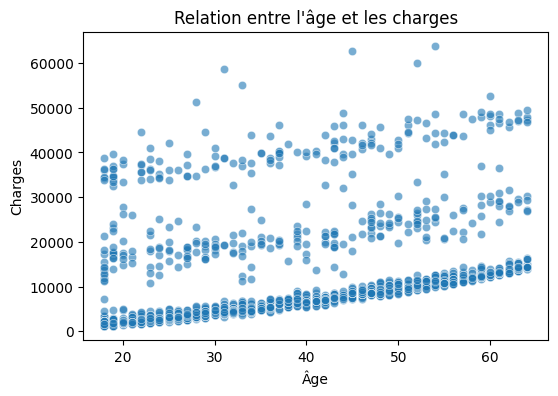

In [56]:
# sans droite de régression
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="charges", data=df, alpha=0.6)
plt.title("Relation entre l'âge et les charges")
plt.xlabel("Âge")
plt.ylabel("Charges")
plt.show()

fig = px.scatter(
    df,
    x="age",
    y="charges",
    opacity=0.6,
    title="Relation entre l'âge et les charges",
    labels={
        "age": "Âge",
        "charges": "Charges"
    },
    trendline="ols"   # ajoute une droite de régression
)

fig.show()

On observe une relation globalement croissante entre l’âge et les charges :
les coûts médicaux tendent à augmenter avec l’âge.

La corrélation est positive mais modérée, indiquant que l’âge
explique une partie de la variabilité des charges,
sans être le seul facteur déterminant.


D’un point de vue métier, cette relation est cohérente avec
l’augmentation des besoins médicaux au fil du vieillissement.

L’âge constitue donc un facteur de risque naturel
dans la tarification des contrats d’assurance.


La relation relativement linéaire entre l’âge et les charges
rend cette variable compatible avec un modèle de régression linéaire.


### Bmi vs Charges

Objectif :
Analyser l’impact de l’indice de masse corporelle (BMI)
sur les charges d’assurance afin d’évaluer le lien
entre état de santé et coûts médicaux.


In [57]:
df[["bmi", "charges"]].corr()


,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


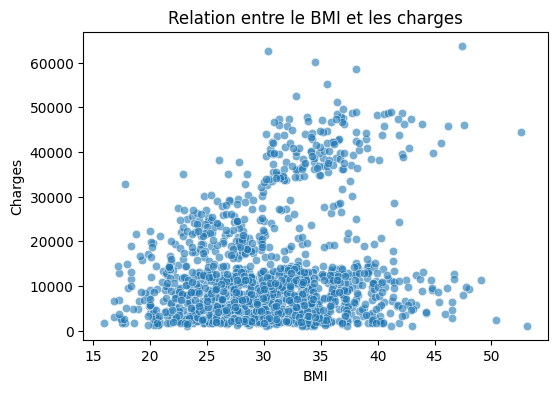

In [58]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="bmi", y="charges", data=df, alpha=0.6)
plt.title("Relation entre le BMI et les charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    opacity=0.6,
    title="Relation entre le BMI et les charges",
    labels={
        "bmi": "BMI",
        "charges": "Charges"
    },
    trendline="ols"   # ajoute une droite de régression (optionnel mais très utile)
)

fig.show()

La relation entre le BMI et les charges est positive mais dispersée.
Les charges tendent à augmenter pour des valeurs élevées de BMI,
mais avec une forte variabilité.

Cette dispersion suggère que le BMI seul ne suffit pas
à expliquer les charges, et que son effet dépend probablement
d’autres facteurs.


D’un point de vue métier, un BMI élevé est associé
à un risque accru de pathologies chroniques,
mais son impact financier dépend également
du profil global de l’assuré.


La variable `bmi` pourra être intégrée au modèle,
et des interactions avec le tabagisme ou l’âge
pourront être explorées afin de mieux capter son effet.


### Children vs charges

Objectif :
Analyser la relation entre le nombre d’enfants à charge
et les charges d’assurance afin d’évaluer son influence
sur les coûts médicaux.


In [59]:
df.groupby("children")["charges"].mean()


children
0    12384.695312
1    12731.171875
2    15073.563477
3    15355.318359
4    13850.656250
5     8786.035156
Name: charges, dtype: float32

In [60]:
df.groupby("children")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
children,,,,,,,,
0,573.0,12384.696289,12025.424805,1121.873901,2741.947998,9863.471680,14449.854492,63770.429688
1,324.0,12731.170898,11823.630859,1711.026855,4791.643188,8483.870117,15632.052002,58571.074219
2,240.0,15073.564453,12891.368164,2304.002197,6284.939575,9264.979492,20379.277344,49577.664062
3,157.0,15355.318359,12330.869141,3443.063965,6652.528809,10600.547852,19199.943359,60021.398438
4,25.0,13850.656250,9139.223633,4504.662598,7512.267090,11033.662109,17128.425781,40182.246094
5,18.0,8786.035156,3808.435547,4687.796875,5874.973999,8589.565430,10019.943848,19023.259766


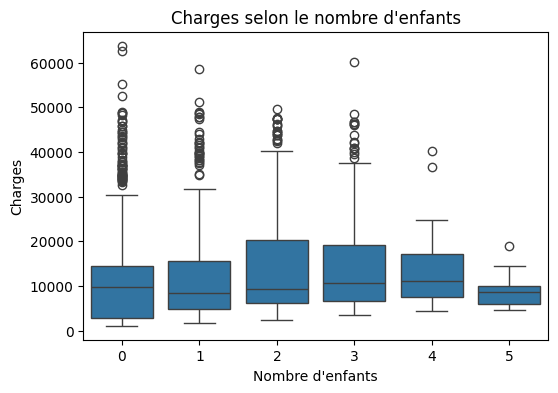

0        True
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337     True
Name: smoker_encoded, Length: 1337, dtype: bool


In [78]:
plt.figure(figsize=(6,4))
sns.boxplot(x="children", y="charges", data=df)
plt.title("Charges selon le nombre d'enfants")
plt.xlabel("Nombre d'enfants")
plt.ylabel("Charges")
plt.show()

fig = px.box(
    df,
    x="children",
    y="charges",
    title="Boxplot des charges selon le nombre d'enfants",
    labels={
        "charges": "Charges",
        "children": "Children"
    }
)

fig.show()
print(df["smoker_encoded"])

Les charges moyennes ne varient pas de manière monotone
avec le nombre d’enfants.

Aucune relation claire ou linéaire ne se dégage,
suggérant un impact limité de cette variable
sur les charges individuelles.


D’un point de vue métier, le nombre d’enfants à charge
n’est pas directement lié aux coûts médicaux individuels,
mais peut refléter des caractéristiques socio-démographiques.


La variable `children` pourra être intégrée au modèle,
mais son pouvoir explicatif est attendu comme faible.


# 4 Analyse des corrélations globales

Objectif :
Analyser les relations linéaires entre les variables numériques
afin d’identifier les facteurs les plus corrélés aux charges
et d’anticiper les choix de modélisation.


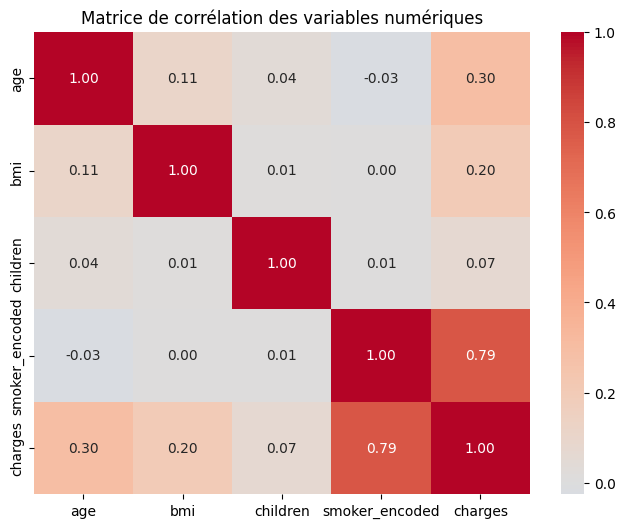

In [61]:
# Heatmap : Corrélation entre variables continues
# Visualise les corrélations entre âge, BMI, nombre d'enfants et charges.(ici nous prenons que les valeurs numériques)

df_num = df.select_dtypes(include="number")
df_num.columns

corr_matrix = df_num.corr()
corr_matrix

plt.figure(figsize=(8,6))
sns.heatmap(
    df[["age", "bmi", "children", "smoker_encoded", "charges"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


En intégrant la variable `smoker`, encodée sous forme binaire (0 = non-fumeur, 1 = fumeur),
la matrice de corrélation met en évidence que le tabagisme est la variable
la plus fortement corrélée aux charges d’assurance.

La corrélation positive élevée entre `smoker` et `charges` confirme
les observations issues de l’analyse bivariée :
les assurés fumeurs génèrent en moyenne des coûts nettement plus importants.

Les variables `age` et `bmi` présentent également une corrélation positive
avec les charges, bien que d’intensité plus modérée.
Ces résultats suggèrent que l’augmentation du risque médical
est progressive avec l’âge et le niveau de BMI.

À l’inverse, la variable `children` montre une corrélation faible avec les charges,
indiquant un impact limité dans un cadre de relation linéaire.

Il est important de souligner que la corrélation calculée pour la variable `smoker`
reflète une relation moyenne entre deux groupes distincts
(fumeurs vs non-fumeurs) et ne capture pas la complexité
des interactions possibles avec d’autres variables comme l’âge ou le BMI.

Enfin, comme toute mesure de corrélation, cette analyse se limite
aux relations linéaires et ne permet pas d’inférer une relation causale.


## Analyse multivariée exploratoire (bonus)

### Interaction smoker × age

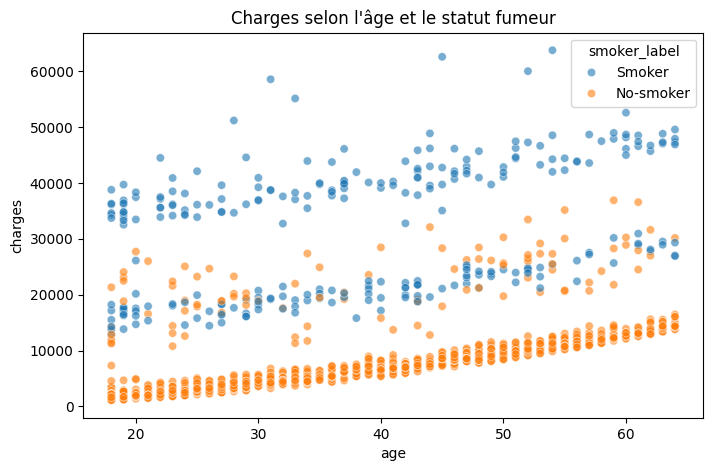

In [62]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="age",
    y="charges",
    hue="smoker_label",
    data=df,
    alpha=0.6
)
plt.title("Charges selon l'âge et le statut fumeur")
plt.show()

fig = px.scatter(
    df,
    x="age",
    y="charges",
    color="smoker_label",
    opacity=0.6,
    title="Charges selon l'âge et le statut fumeur",
    labels={
        "age": "Age",
        "charges": "Charges"
    },
    trendline="ols"   # ajoute une droite de régression (optionnel mais très utile)
)

fig.show()

L’impact du tabagisme sur les charges est visible
à tous les âges, mais tend à s’amplifier
chez les assurés plus âgés.

Cela suggère une possible interaction
entre l’âge et le tabagisme.


### Interaction smoker × bmi

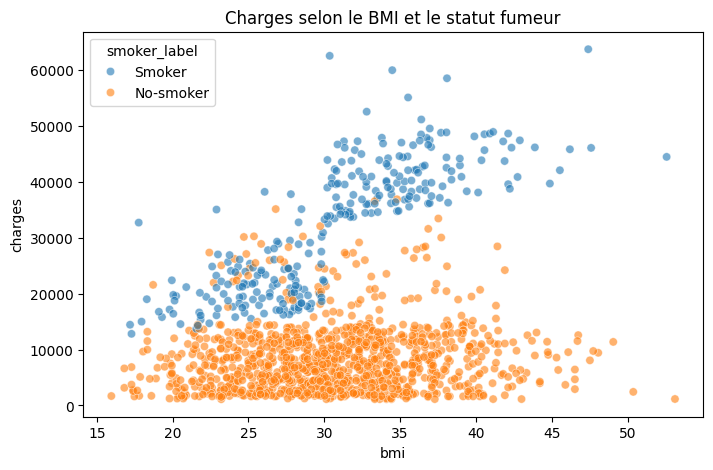

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker_label",
    data=df,
    alpha=0.6
)
plt.title("Charges selon le BMI et le statut fumeur")
plt.show()

fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker_label",
    opacity=0.6,
    title="Charges selon le BMI et le statut fumeur",
    labels={
        "bmi": "Bmi",
        "charges": "Charges"
    },
    trendline="ols"
)

fig.show()


Chez les fumeurs, les charges augmentent fortement
avec le BMI, tandis que cette relation est
moins marquée chez les non-fumeurs.

Cette observation suggère un effet combiné
du tabagisme et du surpoids.


In [64]:
fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker_label",
    size="age",
    symbol="sex",
    opacity=0.6,
    title="Impact combiné du BMI, de l'âge, du sex et du tabagisme sur les charges",
    labels={
        "bmi": "BMI",
        "charges": "Charges",
        "smoker": "Fumeur",
        "age": "Âge",
        "sex": "Sexe"
    },
    trendline="ols"
)

fig.show()

Ce graphique montre que les charges d’assurance sont le résultat d’un effet combiné entre l’âge, l’obésité et le tabagisme. Les assurés les plus coûteux sont majoritairement des fumeurs âgés avec un BMI élevé, ce qui justifie une tarification différenciée et l’utilisation simultanée de ces variables dans le modèle prédictif.

## Conclusion semaine 1

INSIGHT 1 — Impact du tabagisme

In [65]:
df.groupby("smoker_label")["charges"].median()
df.groupby("smoker_label")["charges"].mean()


smoker_label
No-smoker     8440.660156
Smoker       32050.234375
Name: charges, dtype: float32

médiane fumeurs ≈ 34 000

médiane non-fumeurs ≈ 7 000

In [66]:
print(df.groupby("smoker_label")["charges"].median()["Smoker"] / df.groupby("smoker_label")["charges"].median()["No-smoker"])

4.6906657


INSIGHT 2 — Asymétrie des charges

In [67]:
print(df["charges"].skew())
df["charges"].describe()

1.5153909


count     1337.000000
mean     13279.122070
std      12110.359375
min       1121.873901
25%       4746.344238
50%       9386.161133
75%      16657.716797
max      63770.429688
Name: charges, dtype: float64

Skewness >> 1 → distribution fortement tirée vers la droite.

In [68]:
df.groupby("smoker_label")["charges"].std()

smoker_label
No-smoker     5992.973633
Smoker       11541.546875
Name: charges, dtype: float32

Les fumeurs ont un écart-type beaucoup plus élevé → plus de variabilité.

INSIGHT 4 — Moyenne vs Médiane

In [69]:
moyen = df.groupby("smoker_label")["charges"].mean()
mediane = df.groupby("smoker_label")["charges"].median()
print(f"La moyenne est de {moyen}")
print(f"La mediane est de {mediane}")

La moyenne est de smoker_label
No-smoker     8440.660156
Smoker       32050.234375
Name: charges, dtype: float32
La mediane est de smoker_label
No-smoker     7345.726562
Smoker       34456.347656
Name: charges, dtype: float32


La moyenne est largement au-dessus de la médiane → présence d’outliers.

INSIGHT 5 — BMI et charges
Calculs

In [70]:
df["bmi"].corr(df["charges"])

np.float64(0.19840083159871805)

In [71]:
df.groupby("smoker")[["bmi","charges"]].corr()

/tmp/ipykernel_425152/908509128.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



bmi   charges
smoker                            
no     bmi      1.000000  0.084077
       charges  0.084077  1.000000
yes    bmi      1.000000  0.806481
       charges  0.806481  1.000000

Corrélation positive, plus forte chez les fumeurs.

INSIGHT 6 — Non-fumeurs coûteux

In [72]:
Q3 = df[df["smoker_label"]=="No-smoker"]["charges"].quantile(0.75)
Q1 = df[df["smoker_label"]=="No-smoker"]["charges"].quantile(0.25)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR

population = len(df[(df["smoker_label"]=="No-smoker") & (df["charges"]>upper)])
print(f"La population non fumeur mais avec une grande charge médicale est de {population}")
df[(df["smoker_label"]=="No-smoker") & (df["charges"]>upper)]

La population non fumeur mais avec une grande charge médicale est de 46


,age,sex,bmi,children,smoker,region,charges,smoker_encoded,smoker_label,age_group,bmi_category
9,60,female,25.840,0,no,northwest,28923.136719,False,No-smoker,60+,Overweight
62,64,male,24.700,1,no,northwest,30166.619141,False,No-smoker,60+,Normal
115,60,male,28.595,0,no,northeast,30259.996094,False,No-smoker,60+,Overweight
138,54,female,31.900,3,no,southeast,27322.734375,False,No-smoker,50-59,Obese
140,34,male,22.420,2,no,northeast,27375.904297,False,No-smoker,30-39,Normal
219,24,female,23.210,0,no,southeast,25081.767578,False,No-smoker,18-29,Normal
227,58,female,41.910,0,no,southeast,24227.337891,False,No-smoker,50-59,Obese
242,55,female,26.800,1,no,southwest,35160.132812,False,No-smoker,50-59,Overweight
245,54,male,30.020,0,no,northwest,24476.478516,False,No-smoker,50-59,Obese
289,52,male,26.400,3,no,southeast,25992.820312,False,No-smoker,50-59,Overweight


INSIGHT 7 — Enfants

In [73]:
print(df["children"].skew())
df.groupby("children")["charges"].mean()


0.9374206440474123


children
0    12384.695312
1    12731.171875
2    15073.563477
3    15355.318359
4    13850.656250
5     8786.035156
Name: charges, dtype: float32

In [74]:
df["children"].value_counts()


children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

Le nombre d’enfants est positivement lié aux charges jusqu’à 3 enfants, ce qui reflète l’augmentation du nombre de personnes couvertes. Pour les familles très nombreuses (4–5 enfants), les données sont trop rares pour tirer une conclusion fiable.

INSIGHT 8 — Justification du log

In [75]:
df["charges"].skew() 

np.float32(1.5153909)

In [76]:
np.log(df["charges"]).skew()

np.float32(-0.08983863)

La skewness devient proche de 0.

La transformation logarithmique de la variable cible réduit fortement son asymétrie, rendant la distribution plus proche d’une loi normale, ce qui améliore la stabilité et la performance d’un modèle de régression linéaire.

In [79]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Insurance Dataset – EDA Report",
    explorative=True
)




In [80]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 70546.40it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]